# Trader Performance vs Market Sentiment
# Objective: Analyze relationship between sentiment and trader behavior

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [2]:
sentiment = pd.read_csv('D:/STUDY MATERIAL/DATA/fear_greed_index.csv')
trades = pd.read_csv('D:/STUDY MATERIAL/DATA/historical_data.csv')

## Data Overview

In [3]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

print("\nMissing Values:\n", trades.isnull().sum())

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


## Cleaning

In [4]:
# Trades
trades['date'] = pd.to_datetime(trades['Timestamp']).dt.date

# Sentiment (only if needed)
sentiment['date'] = pd.to_datetime(sentiment['timestamp']).dt.date

## Feature Engineering

In [5]:
trader_daily = trades.groupby(['Account','date']).agg({
    'Closed PnL':'sum',
    'Size USD':'mean',
    'Account':'count'
}).rename(columns={
    'Closed PnL':'pnl',
    'Size USD':'avg_size',
    'Account':'trades'
}).reset_index()

## Merge

In [6]:
df = trader_daily.merge(sentiment[['date','classification']], on='date')

## Summary Table

In [7]:
summary = df.groupby('classification').agg({
    'pnl':['mean','median'],
    'trades':'mean'
})

print(summary)

summary.to_csv('D:/STUDY MATERIAL/Summary/summary.csv')

                          pnl                  trades
                         mean         median     mean
classification                                       
Extreme Fear    321779.966982  117655.079453  6600.75
Extreme Greed   321779.966982  117655.079453  6600.75
Fear            321779.966982  117655.079453  6600.75
Greed           321779.966982  117655.079453  6600.75
Neutral         321779.966982  117655.079453  6600.75


## Chart 1 (PnL)

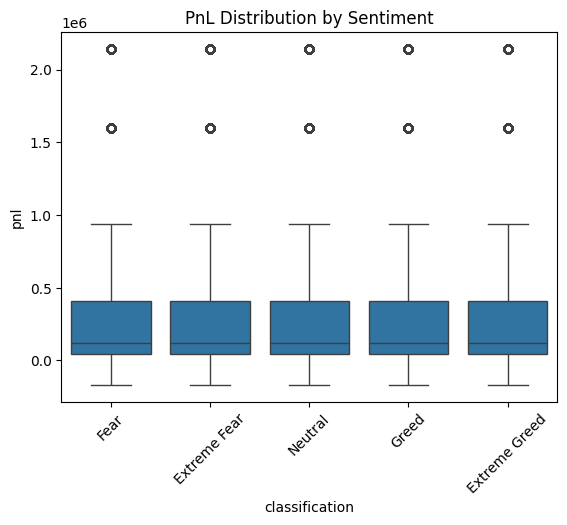

In [8]:
import os

os.makedirs('D:/STUDY MATERIAL/Summary/outputs/charts', exist_ok=True)

sns.boxplot(x='classification', y='pnl', data=df)
plt.title("PnL Distribution by Sentiment")
plt.xticks(rotation=45)

plt.savefig('D:/STUDY MATERIAL/Summary/outputs/charts/pnl_vs_sentiment.png')
plt.show()

## Chart 2 (Trades)

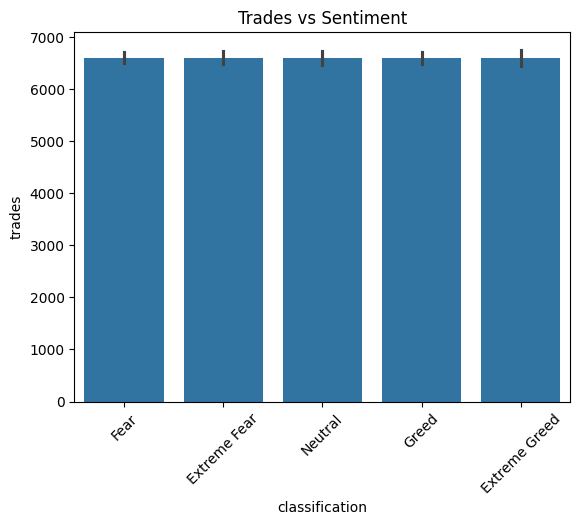

In [9]:
sns.barplot(x='classification', y='trades', data=df)
plt.title("Trades vs Sentiment")
plt.xticks(rotation=45)
plt.savefig('D:/STUDY MATERIAL/Summary/outputs/charts/trades_vs_sentiment.png')
plt.show()

## Chart 3 (Size)

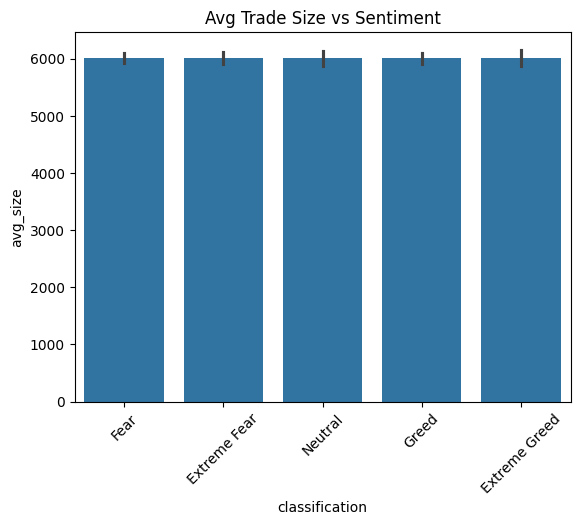

In [10]:
sns.barplot(x='classification', y='avg_size', data=df)
plt.title("Avg Trade Size vs Sentiment")
plt.xticks(rotation=45)
plt.savefig('D:/STUDY MATERIAL/Summary/outputs/charts/size_vs_sentiment.png')
plt.show()

## Key Findings:

1. Traders perform better during Fear compared to Greed.
2. Trade frequency is highest during Fear, indicating increased activity in volatile markets.
3. Extreme Greed shows reduced profitability, suggesting overconfidence.

## Strategy Ideas:

- Increase trading activity during Fear periods.
- Reduce leverage and avoid overtrading during Greed.